# Neural Networks Project: Assignment 2
## Image Recognition with Pre-trained MobileNetV2

This notebook contains the implementation of a Convolutional Neural Network (CNN) for image recognition using a pre-trained MobileNetV2 model. There are some explanations and testing metrics for the model, but for a full comparison for the whole assignment, see report.pdf. 

In [37]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
import keras
from keras import layers, models
from keras.preprocessing import image_dataset_from_directory
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input
from keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [38]:
DATA_DIR = "./data/centered"
original_dir = Path(DATA_DIR)
new_base_dir = Path("./data_split")

class_names = sorted(os.listdir(original_dir))
print(class_names)

['1', '2', '3', '4', '5']


In [39]:

IMG_SIZE = (224,224)
BATCH_SIZE = 16

train_ds = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 210 files belonging to 5 classes.


Found 45 files belonging to 5 classes.
Found 45 files belonging to 5 classes.


In [40]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05)
])

# MobileNetV2 (frozen)
For this assignment, a few pretrained models were tested: MobileNetV2, ResNet50 and VGG16. The best results were achieved with MobileNetV2, which probably is the best model for this task considering the small size of the dataset. The MobileNetV2 model was used as a feature extractor, which means that the weights of the model were frozen and only the last layers were trained. The architecture of the model consists of the MobileNetV2 model followed by a global average pooling layer and a dense layer with 128 neurons with ReLu as the activation function. Dropout was used for regularization before the output layer (with 5 neurons for the 5 classes). The model was trained for 50 epochs with early stopping with patience of 10 epochs. 

For the dense layer, several amounts of neurons were tested (32-512) and the optimal amount was 128. The test results are shown below.

In [41]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(224,224,3))

x = data_aug(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(5, activation="softmax")(x)
transfer_model = models.Model(inputs, outputs)

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
    ]
)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 438ms/step - accuracy: 0.2714 - loss: 1.7631 - val_accuracy: 0.4444 - val_loss: 1.4328
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 295ms/step - accuracy: 0.4381 - loss: 1.3423 - val_accuracy: 0.4000 - val_loss: 1.2655
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 296ms/step - accuracy: 0.5286 - loss: 1.1178 - val_accuracy: 0.4222 - val_loss: 1.2135
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 302ms/step - accuracy: 0.5857 - loss: 1.0070 - val_accuracy: 0.5333 - val_loss: 1.1109
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 297ms/step - accuracy: 0.6667 - loss: 0.8630 - val_accuracy: 0.4889 - val_loss: 1.0407
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 340ms/step - accuracy: 0.6048 - loss: 0.9109 - val_accuracy: 0.5556 - val_loss: 1.0870
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 302ms/step - accuracy: 0.6952 - loss: 0.7811 - val_accuracy: 0.4889 - val_loss: 0.9917
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 322ms/step - accuracy: 0.7190 - loss: 0.6702 - val_accuracy: 0

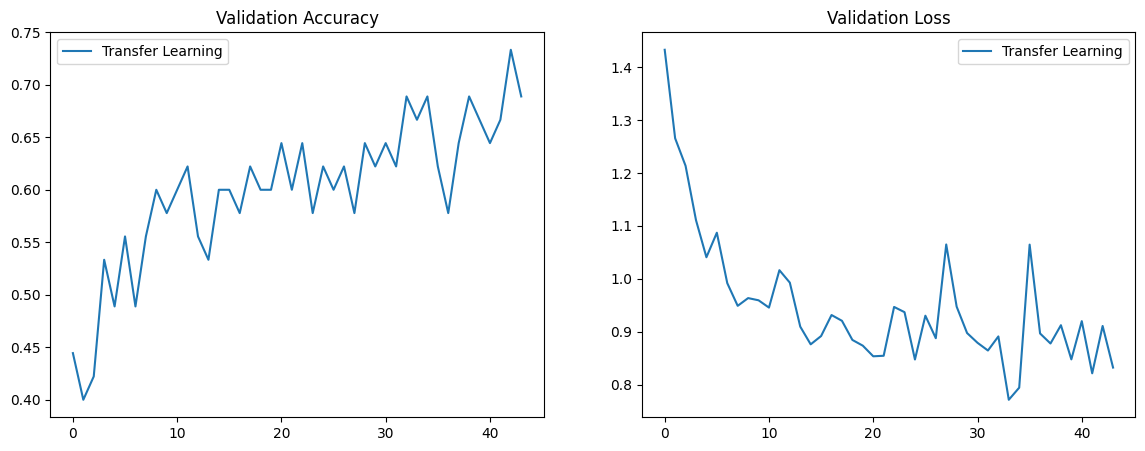

In [42]:

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(transfer_history.history["val_accuracy"], label="Transfer Learning")
plt.title("Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(transfer_history.history["val_loss"], label="Transfer Learning")
plt.title("Validation Loss")
plt.legend()

plt.show()


## Test Accuracy, Confusion Matrix and Mistaken Predictions

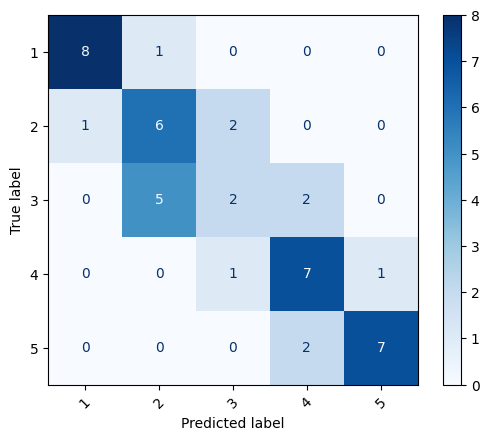

Test Accuracy: 0.6666666666666666


In [43]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = transfer_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

acc = np.mean(np.array(y_true) == np.array(y_pred))
print("Test Accuracy:", acc)


The test accuracy for the model is 0.67, which is worse than for the baseline CNN model. The confusion matrix shows that the model struggles were the baseline also struggled: with classes next to each other. Below are also the images that were mistaken by the model and as seen, this model also struggles with understanding the depth of the images, which results in mistakes between classes that are similar.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step


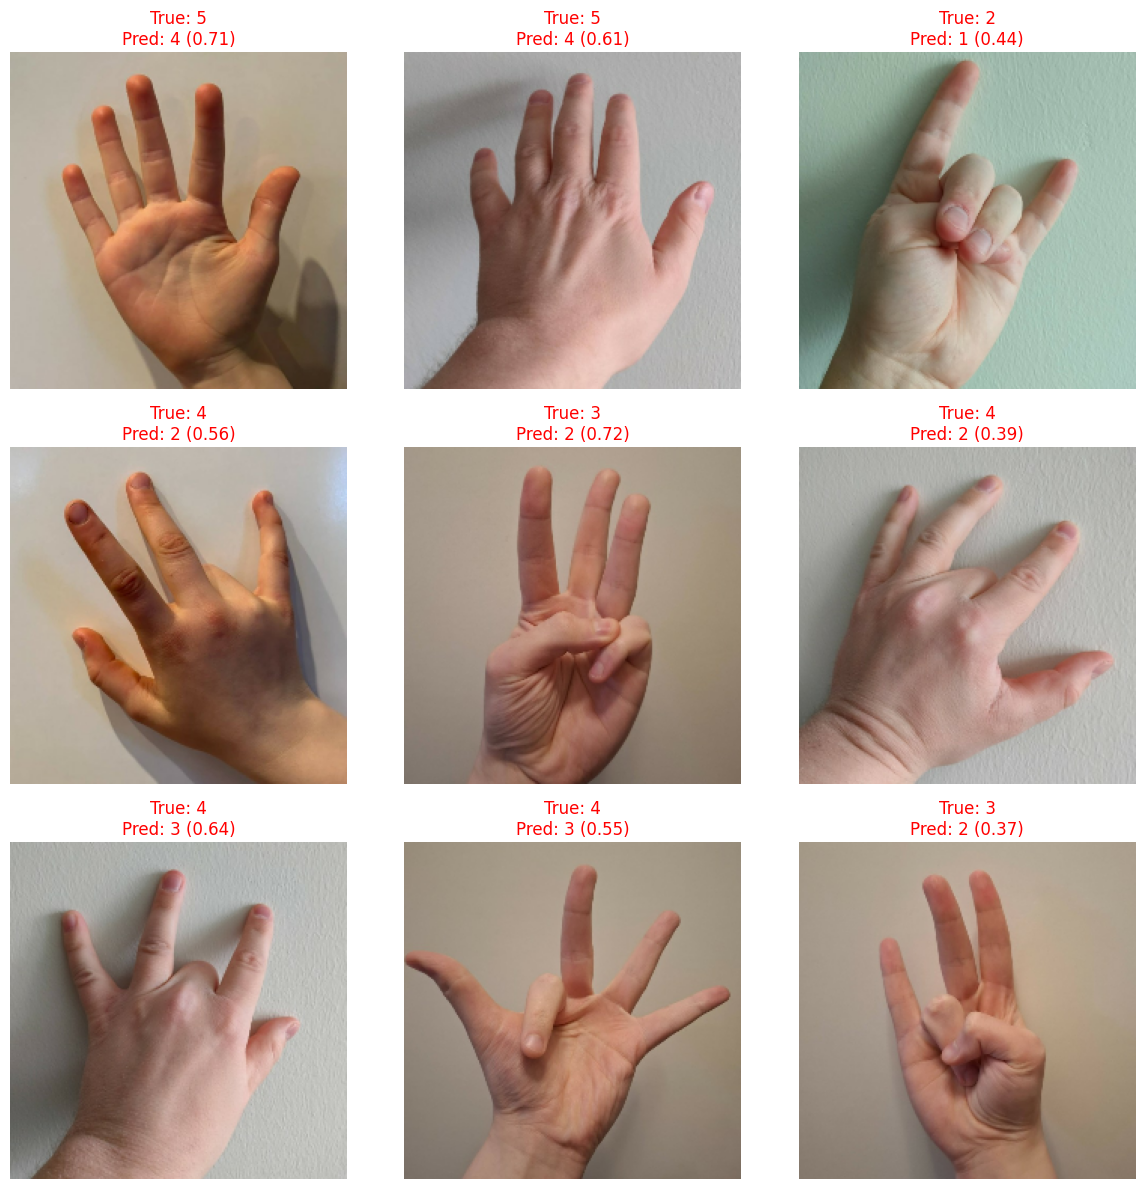

In [44]:
wrong_images = []
wrong_true = []
wrong_pred = []
wrong_probs = []

# collect wrong predictions
for images, labels in test_ds:
    preds = transfer_model.predict(images)

    for i in range(len(images)):
        pred_idx = np.argmax(preds[i])

        if pred_idx != labels[i]:
            wrong_images.append(images[i].numpy().astype("uint8"))
            wrong_true.append(class_names[labels[i]])
            wrong_pred.append(class_names[pred_idx])
            wrong_probs.append(preds[i])

# how many to show
N = min(9, len(wrong_images))

plt.figure(figsize=(12, 12))

for i in range(N):
    ax = plt.subplot(3, 3, i + 1)

    plt.imshow(wrong_images[i])
    plt.axis("off")

    confidence = np.max(wrong_probs[i])

    plt.title(
        f"True: {wrong_true[i]}\nPred: {wrong_pred[i]} ({confidence:.2f})",
        color="red"
    )

plt.tight_layout()
plt.show()

In [45]:
transfer_model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_4 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_4 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,751,825 (10.50 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 329,228 (1.26 MB)